<a href="https://colab.research.google.com/github/spoonylamp/spoonylamp/blob/main/%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B2%D0%BE%D1%80%D0%BE%D0%BD%D0%BA%D0%B8_%D0%B8_%D1%83%D0%B4%D0%B5%D1%80%D0%B6%D0%B0%D0%BD%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_users = 1000
user_ids = np.arange(1, n_users + 1)
data = []

# Генерация данных
for user in user_ids:
    first_visit = np.random.randint(1, 10)
    data.append([user, "визит", first_visit])

    if np.random.rand() < 0.7:
        reg_day = first_visit + np.random.randint(0, 2)
        data.append([user, "регистрация", reg_day])

        if np.random.rand() < 0.3:
            purchase_day = reg_day + np.random.randint(0, 3)
            data.append([user, "покупка", purchase_day])

    for day in range(1, 8):
        if np.random.rand() < 0.2:
            data.append([user, "возврат", first_visit + day])

df = pd.DataFrame(data, columns=["user_id", "событие", "день"])

df.head()

,user_id,событие,день
0,1,визит,7
1,1,возврат,8
2,1,возврат,12
3,2,визит,8
4,2,возврат,9


In [3]:
visits = df[df["событие"] == "визит"]["user_id"].nunique()
registrations = df[df["событие"] == "регистрация"]["user_id"].nunique()
purchases = df[df["событие"] == "покупка"]["user_id"].nunique()

print("Визиты:", visits)
print("Регистрации:", registrations)
print("Покупки:", purchases)

cr_visit_to_reg = registrations / visits
cr_reg_to_purchase = purchases / registrations
cr_total = purchases / visits

print("Конверсия визит - регистрация:", round(cr_visit_to_reg, 2))
print("Конверсия регистрация - покупка:", round(cr_reg_to_purchase, 2))
print("Общая конверсия:", round(cr_total, 2))

Визиты: 1000
Регистрации: 721
Покупки: 207
Конверсия визит - регистрация: 0.72
Конверсия регистрация - покупка: 0.29
Общая конверсия: 0.21


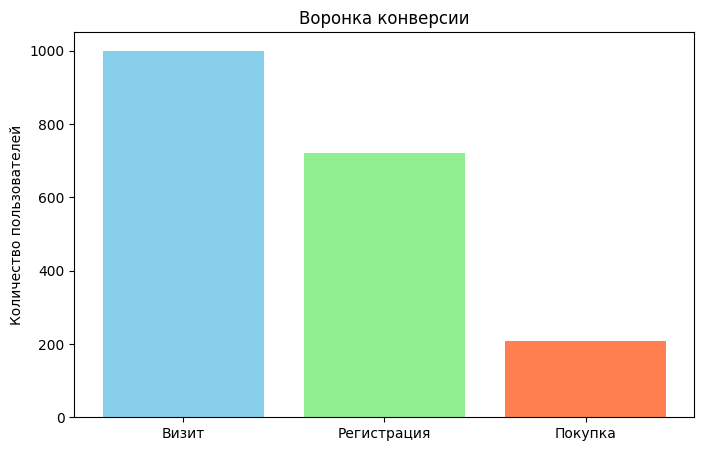

In [4]:
stages = ["Визит", "Регистрация", "Покупка"]
values = [visits, registrations, purchases]

plt.figure(figsize=(8, 5))
plt.bar(stages, values, color=['skyblue', 'lightgreen', 'coral'])
plt.title("Воронка конверсии")
plt.ylabel("Количество пользователей")
plt.show()

In [5]:
first_visit = df[df["событие"] == "визит"][["user_id", "день"]]
first_visit.columns = ["user_id", "день первого визита"]

df = df.merge(first_visit, on="user_id")
df["разница дней"] = df["день"] - df["день первого визита"]

returns = df[df["событие"] == "возврат"]
retention = returns.groupby("разница дней")["user_id"].nunique() / n_users

print("\nУдержание по дням:")
print(retention)


Удержание по дням:
разница дней
1    0.200
2    0.198
3    0.189
4    0.201
5    0.198
6    0.214
7    0.194
Name: user_id, dtype: float64


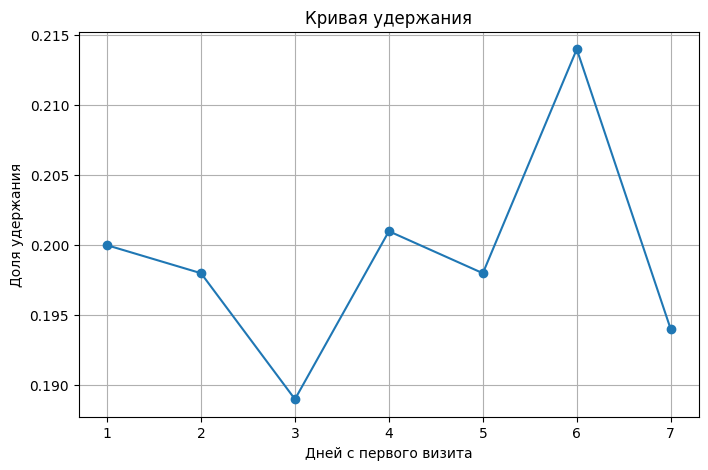

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(retention.index, retention.values, marker='o')
plt.title("Кривая удержания")
plt.xlabel("Дней с первого визита")
plt.ylabel("Доля удержания")
plt.grid(True)
plt.show()

**КЛЮЧЕВЫЕ ВЫВОДЫ**
1. Конверсия из захода в регистрацию составляет ~70%, что высоко
2. Конверсия из регистрации в покупку сильно ниже ~30%, что говорит о возможных проблемах на этапе монетизации
3. Общая конверсия в покупку ~20–25%
4. Основное падение пользователей происходит между регистрацией и покупкой
5. Удержание быстро снижается в первые дни - это возможный признак низкой ценности продукта или недостаточной вовлечённости пользователей

**ГИПОТЕЗЫ**
- Проблема на этапе покупки.

Возможная причина: сложный процесс оплаты или недостаточная мотивация.

Решение: упростить процесс покупки - повысится конверсия

- Низкое удержание

Возможная причина: пользователь не видит ценности продукта.

Решение: добавить рекомендации - увеличится возврат

- Недостаточная вовлечённость после регистрации.

Решение: отправка уведомлений или email-рассылки повысит удержание